# Day 08: Algısal Renk Uzayı Analizi ve Renk Eşikleme

> **Aşama:** Faz 2: Endüstriyel Görüntü İşleme  
> **Konu:** RGB Sınırlılıkları, HSV Dairesel Kırılımı, CIELAB ve CIE 1976 Delta E (ΔE*) ile İplik Parti Kalite Denetimi  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Tarih:** 2026-09-04  
> **Lisans:** Özel Lisans — Tüm Hakları Saklıdır (c) 2026 Seydi Eryılmaz  

---

## 1. Problem Tanımı: İplik Boyahanelerinde Renk Sapmaları, Parti Kayması ve RGB Sınırlılıkları

Merinos fabrikasında üretilen halılarda desenlerin kusursuz görünmesi, kullanılan iplik bobinlerinin tam olarak hedeflenen renk standardına uymasına bağlıdır. Farklı boyama partilerinde (dye lots) su sıcaklığı, kimyasal konsantrasyonu ve kurutma süresi gibi etkenler ipliklerde hafif ton kaymalarına yol açar.

Bu denetimde standart **RGB** renk uzayını kullanmak iki temel nedenden dolayı başarısız olur:
1. **Algısal Homojen Olmama (Non-uniformity):** RGB uzayında aynı sayısal Öklid mesafesi (örneğin $\Delta = 10$), yeşil bölgede gözle zor fark edilirken mavi ve kırmızı tonlarda bariz bir renk uyumsuzluğu olarak algılanır (MacAdam Elipsleri).
2. **Işık Değişimlerine Duyarlılık:** Tezgâh üzerindeki bir gölge RGB'nin her üç bileşenini de ($R, G, B$) aynı anda düşürür; bu da renk ayrıştırma algoritmalarının kafasını karıştırır.

Bu laboratuvarda, aydınlatmadan bağımsız **HSV** uzayını ve insan gözünün algısal farklarını doğrudan modelleyen **CIELAB (CIE $L^* a^* b^*$)** uzayı ile $\Delta E^*_{ab}$ tolerans sistemini kuracağız.

## 2. Neden Önemli? (Fiziksel Bobin Uyuşmazlığı, Müşteri Şikayetleri ve İade Maliyetleri)

Tekstil sektöründe renk sapmaları en yüksek maliyetli kalite kontrol sorunlarından biridir:
- Eğer bir parti sapması dokuma başlamadan önce fark edilmezse, binlerce metrekare halı hatalı tonla dokunur.
- Yan yana serilen iki parça halıda $\Delta E^* \ge 2.0$ üzerindeki ton farkları insan gözü tarafından anında yakalanır ve 'farklı ürün' algısı yaratarak müşteri iadesine yol açar.
- Otomatik kalite denetim kameralarının $\Delta E^* < 2.0$ (PASS), $2.0 \le \Delta E^* < 5.0$ (WARNING) ve $\Delta E^* \ge 5.0$ (REJECT) sınıflandırmasını gerçek zamanlı ($>100\text{ FPS}$) yapabilmesi gerekir.

## 3. Matematiksel & Algoritmik Temeller

### 1. CIELAB Renk Uzayı ve D65 Dönüşümü
sRGB değerleri önce gama açılımı ile lineer hale getirilir, ardından CIE 1931 XYZ tristimulus uzayına ve oradan CIELAB uzayına projekte edilir:
$$L^* = 116 f(Y/Y_n) - 16$$
$$a^* = 500 [f(X/X_n) - f(Y/Y_n)]$$
$$b^* = 200 [f(Y/Y_n) - f(Z/Z_n)]$$
Burada $X_n, Y_n, Z_n$ D65 standart gün ışığı referans beyaz noktasıdır.

### 2. CIE 1976 Renk Farkı Formülü ($\Delta E^*_{ab}$)
$$\Delta E^*_{ab} = \sqrt{(\Delta L^*)^2 + (\Delta a^*)^2 + (\Delta b^*)^2}$$
Bu mesafe doğrudan insan gözünün algıladığı renk farkı olan **Just Noticeable Difference (JND)** ile orantılıdır.

### 3. HSV Dairesel Hue Kırılımı (Circular Wrap-around)
HSV uzayında Renk Özü ($H$) $0^\circ$ ile $360^\circ$ arasında dairesel bir silindirdir (OpenCV'de 8-bit için $0-180$). Kırmızı renk $0^\circ$ etrafında ortalandığı için spektrum ikiye bölünür:
$$\text{Red Mask} = (H \in [0, 10]) \cup (H \in [170, 180])$$
Bu durum bitwise OR operasyonuyla birleştirilmezse kırmızı iplikler ortadan yarılır ve delikli maskeler oluşur.

## 4. Kütüphane & Donanım İncelemesi

| Kütüphane | $\Delta E$ Desteği | Hız / SIMD | Renk Uzayları | Endüstriyel Değerlendirme |
| :--- | :--- | :--- | :--- | :--- |
| **OpenCV (`cv2`)** | ⚡ Matrisel Hızlı | AVX2 / IPP SIMD | BGR, HSV, LAB, YCrCb | **Üretim & Gerçek Zamanlı Kamera Denetimi** |
| **colour-science** | 🔬 Çok Yüksek (CIE2000, CAM16) | Orta | 50+ Spektral model | Akademik / Spektrometre Kalibrasyonu |
| **scikit-image** | ⚖️ İyi | NumPy vektörel | RGB, HSV, LAB | Genel Veri Bilimi |
| **colormath** | ⚠️ Yavaş | Python saf döngü | Standart | Bakımsız (Legacy) |

## 5. Minimal Çalışır Kod: İki İplik Rengi Arasında Delta E Hesaplanması ve Tolerans Sınıflandırması

In [1]:
import sys
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Day 08 mini_project modüllerini dinamik ve güvenli içeri aktarma
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day08" else CURRENT_DIR
DAY08_DIR = PROJECT_ROOT / "day08"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day08.mini_project.src.conversions import ColorConverter
from day08.mini_project.src.delta_e import DeltaECalculator
from day08.mini_project.src.analyzer import CarpetColorAnalyzer
from day08.mini_project.src.thresholding import HSVColorThresholder, PerceptualDeltaEThresholder

# İki iplik örneği: Merinos Referans Kırmızı vs Boyahaneden Gelen Örnek Kırmızı
ref_hex = '#8B0000'
sample_hex = '#960000'

ref_lab = ColorConverter.rgb_to_cielab_exact(ColorConverter.hex_to_rgb(ref_hex))
sample_lab = ColorConverter.rgb_to_cielab_exact(ColorConverter.hex_to_rgb(sample_hex))

diff = DeltaECalculator.calculate_delta_e_cie76(ref_lab, sample_lab)
print(f'Referans Kırmızı ({ref_hex}): LAB = {ref_lab}')
print(f'Parti Kırmızı ({sample_hex}): LAB = {sample_lab}')
print(f'Delta E* (CIE 1976): {diff.delta_e} -> QA Kararı: {diff.grade.value}')
print(f'Açıklama: {diff.interpretation}')


Referans Kırmızı (#8B0000): LAB = (28.09, 51.0, 41.29)
Parti Kırmızı (#960000): LAB = (30.61, 53.91, 44.34)
Delta E* (CIE 1976): 4.911 -> QA Kararı: WARNING
Açıklama: Gözle fark edilebilir ton kayması; tezgâh veya boya banyosu uyarısı.


## 6. Deney 1: RGB vs HSV vs CIELAB Görselleştirme ve Renk Uzayı Karşılaştırması

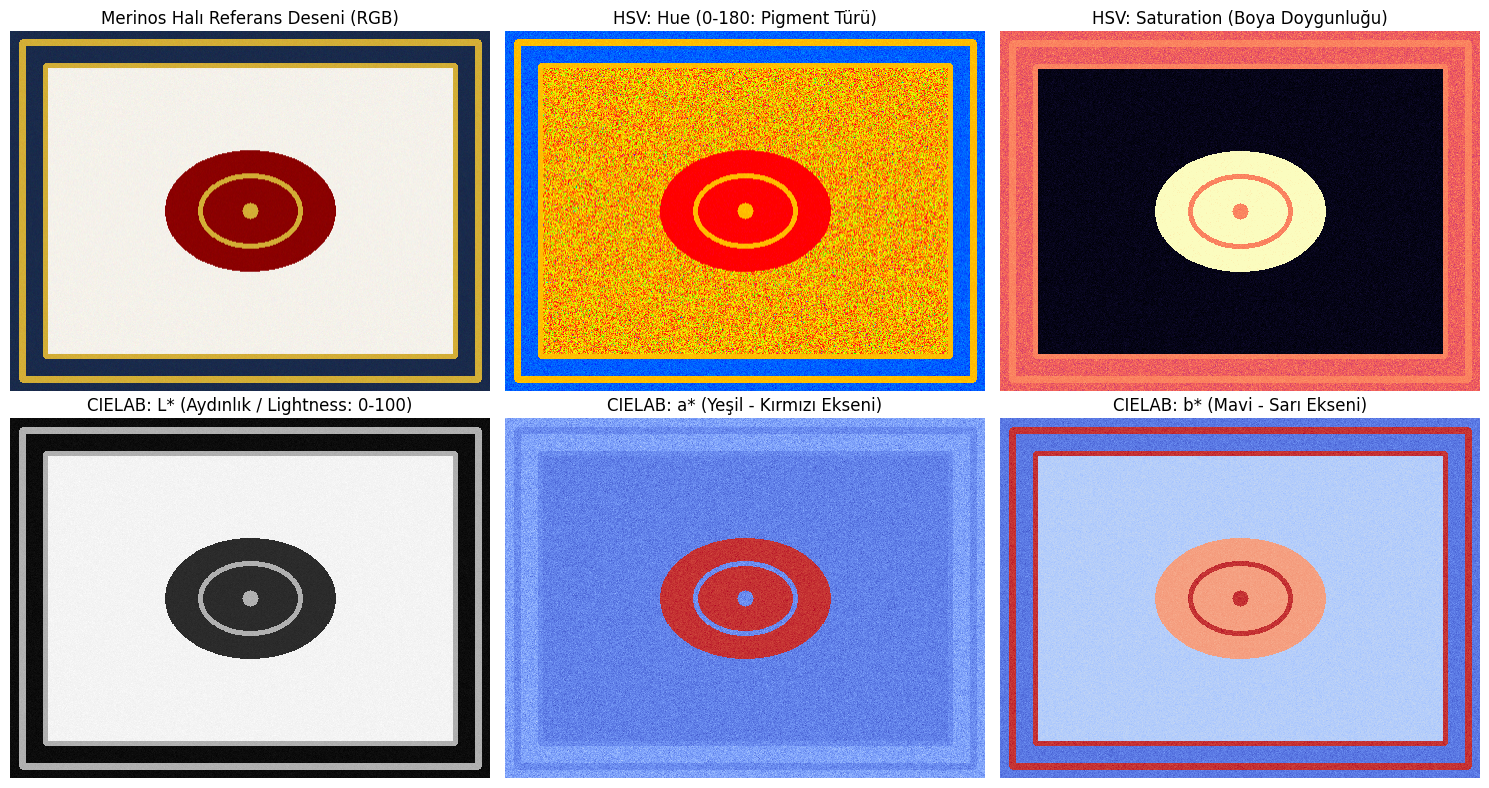

In [2]:
import sys
from pathlib import Path

# Güvenli yol çözümleme
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "day08" else CURRENT_DIR
DAY08_DIR = PROJECT_ROOT / "day08"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

fixtures_dir = DAY08_DIR / "mini_project" / "fixtures" / "synthetic_carpets"
if not fixtures_dir.exists():
    fixtures_dir = Path("day08/mini_project/fixtures/synthetic_carpets")

master_path = fixtures_dir / 'carpet_palette_master.png'

raw_bytes = np.fromfile(str(master_path), dtype=np.uint8)
master_bgr = cv2.imdecode(raw_bytes, cv2.IMREAD_COLOR)
master_rgb = cv2.cvtColor(master_bgr, cv2.COLOR_BGR2RGB)

master_hsv = cv2.cvtColor(master_bgr, cv2.COLOR_BGR2HSV)
master_lab = ColorConverter.bgr_image_to_cielab_float(master_bgr)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(master_rgb)
axes[0, 0].set_title('Merinos Halı Referans Deseni (RGB)')
axes[0, 1].imshow(master_hsv[:, :, 0], cmap='hsv')
axes[0, 1].set_title('HSV: Hue (0-180: Pigment Türü)')
axes[0, 2].imshow(master_hsv[:, :, 1], cmap='magma')
axes[0, 2].set_title('HSV: Saturation (Boya Doygunluğu)')

axes[1, 0].imshow(master_lab[:, :, 0], cmap='gray')
axes[1, 0].set_title('CIELAB: L* (Aydınlık / Lightness: 0-100)')
axes[1, 1].imshow(master_lab[:, :, 1], cmap='coolwarm')
axes[1, 1].set_title('CIELAB: a* (Yeşil - Kırmızı Ekseni)')
axes[1, 2].imshow(master_lab[:, :, 2], cmap='coolwarm')
axes[1, 2].set_title('CIELAB: b* (Mavi - Sarı Ekseni)')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


## 7. Deney 2: HSV Dairesel Kırılım Deneyi (Imperial Red Hue Wrap-Around Analizi)

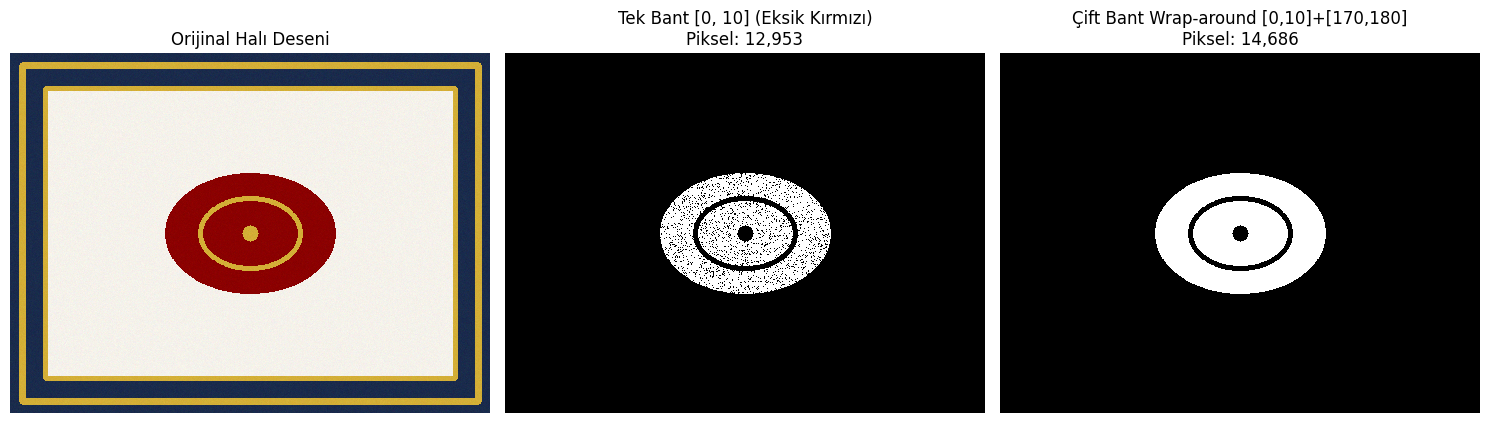

In [3]:
# Kırmızı maskelemede wrap-around etkisini gösterme
# Tek bant: salt [0, 10] aralığı
single_band_mask = HSVColorThresholder.create_mask(master_bgr, lower=(0, 140, 40), upper=(10, 255, 220))

# Çift bant: [0, 10] VEYA [170, 180] (Doğru wrap-around)
dual_band_mask = HSVColorThresholder.create_mask(
    master_bgr,
    lower=(0, 140, 40),
    upper=(10, 255, 220),
    lower2=(170, 140, 40),
    upper2=(180, 255, 220),
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(master_rgb)
axes[0].set_title('Orijinal Halı Deseni')
axes[0].axis('off')

axes[1].imshow(single_band_mask, cmap='gray')
axes[1].set_title(f'Tek Bant [0, 10] (Eksik Kırmızı)\nPiksel: {np.count_nonzero(single_band_mask):,}')
axes[1].axis('off')

axes[2].imshow(dual_band_mask, cmap='gray')
axes[2].set_title(f'Çift Bant Wrap-around [0,10]+[170,180]\nPiksel: {np.count_nonzero(dual_band_mask):,}')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 8. Deney 3: Aydınlatma Dalgalanmalarına Direnç (Gölge ve Parlama Altında Renk Segmentasyonu)

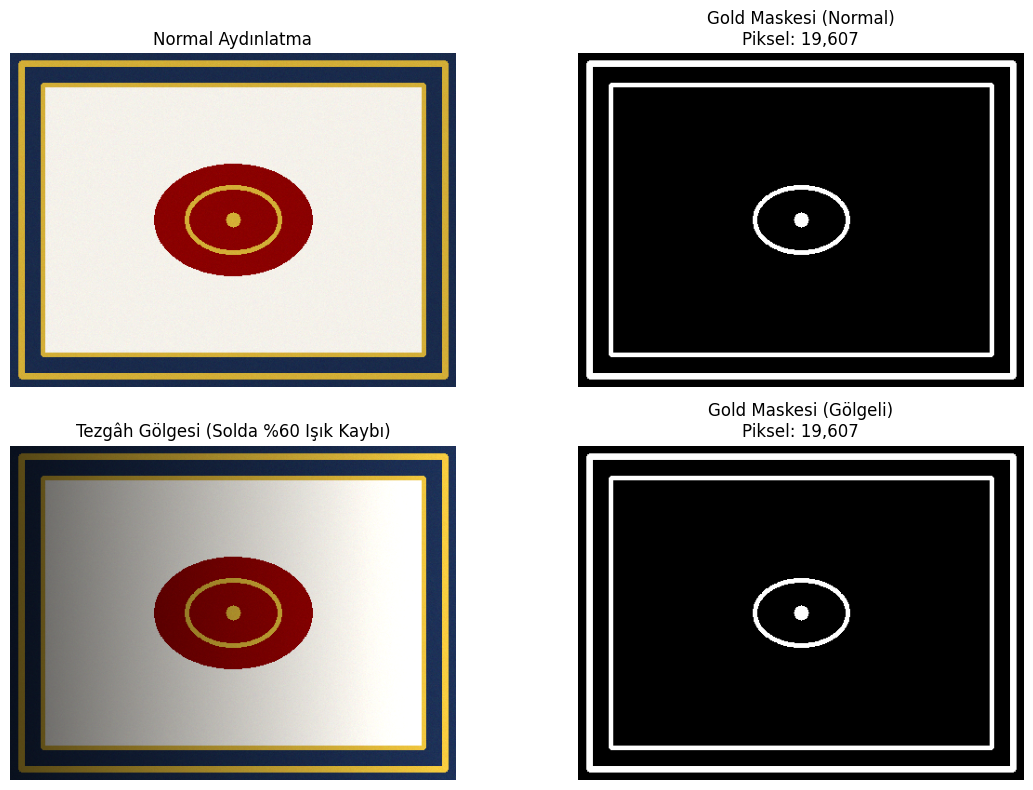

Gölge Altında Piksel Korunma Oranı: 100.0%


In [4]:
# Halı üzerine yapay gölge gradyanı bindirme
h, w = master_bgr.shape[:2]
shadow_gradient = np.linspace(0.4, 1.2, w, dtype=np.float32).reshape(1, w, 1)
shadowed_bgr = np.clip(master_bgr.astype(np.float32) * shadow_gradient, 0, 255).astype(np.uint8)

# HSV ile Antique Gold segmentasyonu
gold_mask_normal = HSVColorThresholder.create_mask(master_bgr, lower=(20, 140, 80), upper=(35, 255, 255))
gold_mask_shadow = HSVColorThresholder.create_mask(shadowed_bgr, lower=(20, 140, 50), upper=(35, 255, 255))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(master_rgb)
axes[0, 0].set_title('Normal Aydınlatma')
axes[0, 1].imshow(gold_mask_normal, cmap='gray')
axes[0, 1].set_title(f'Gold Maskesi (Normal)\nPiksel: {np.count_nonzero(gold_mask_normal):,}')

axes[1, 0].imshow(cv2.cvtColor(shadowed_bgr, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Tezgâh Gölgesi (Solda %60 Işık Kaybı)')
axes[1, 1].imshow(gold_mask_shadow, cmap='gray')
axes[1, 1].set_title(f'Gold Maskesi (Gölgeli)\nPiksel: {np.count_nonzero(gold_mask_shadow):,}')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'Gölge Altında Piksel Korunma Oranı: {np.count_nonzero(gold_mask_shadow) / np.count_nonzero(gold_mask_normal) * 100:.1f}%')


## 9. Deney 4: Merinos Halı Kataloğunda Otomatik İplik Boyama Partisi (Dye Lot) Kalite Denetimi

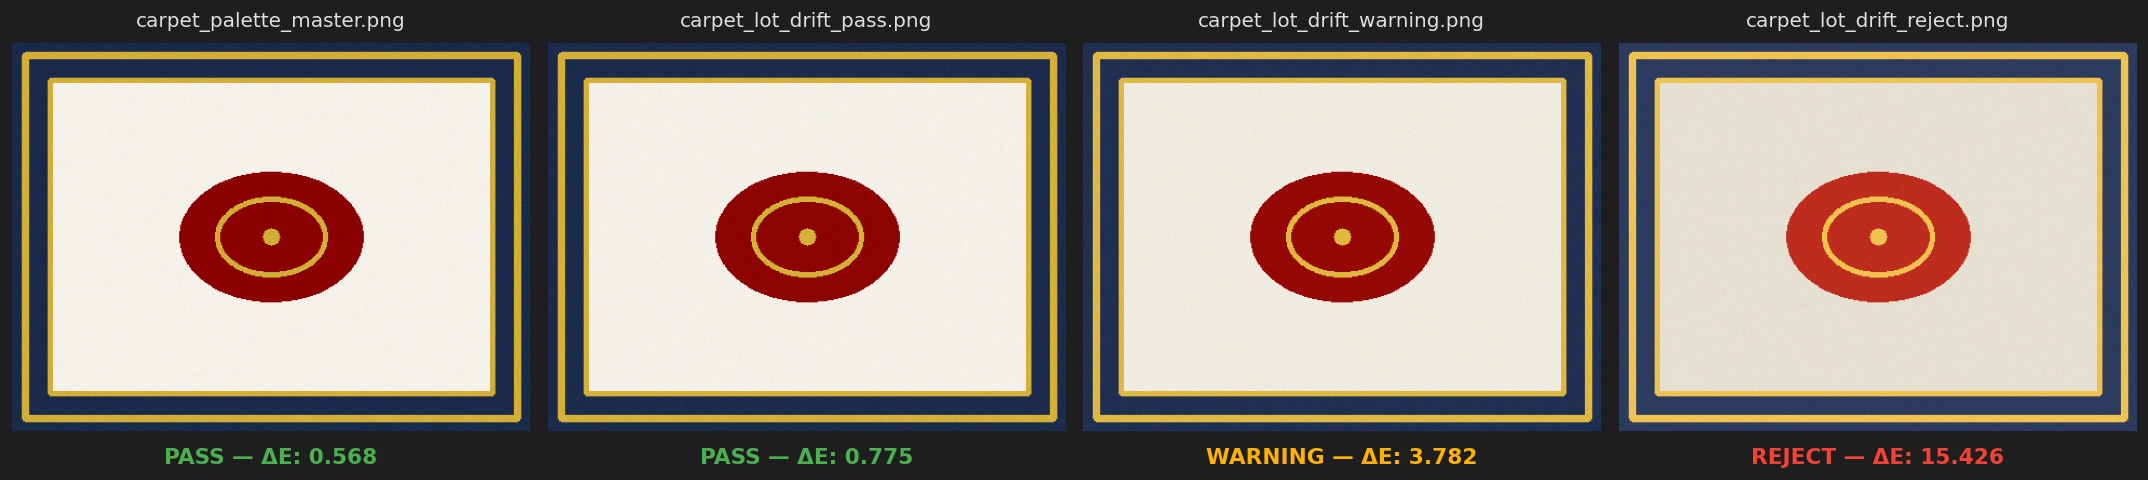

In [5]:
analyzer = CarpetColorAnalyzer()
test_files = [
    'carpet_palette_master.png',
    'carpet_lot_drift_pass.png',
    'carpet_lot_drift_warning.png',
    'carpet_lot_drift_reject.png',
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), facecolor='#1e1e1e', dpi=120)
status_colors = {
    'PASS': '#4caf50',
    'WARNING': '#ffb300',
    'REJECT': '#f44336',
}

for idx, fname in enumerate(test_files):
    p = fixtures_dir / fname
    bytes_arr = np.fromfile(str(p), dtype=np.uint8)
    img = cv2.imdecode(bytes_arr, cv2.IMREAD_COLOR)
    report, _ = analyzer.analyze_carpet(img, p.stem)
    
    ax = axes[idx]
    ax.set_facecolor('#1e1e1e')
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(fname, color='#e0e0e0', fontsize=12, pad=10, fontweight='medium')
    
    color_code = status_colors.get(report.overall_status.value, '#ffffff')
    status_label = f'{report.overall_status.value} — ΔE: {report.max_delta_e:.3f}'
    ax.set_xlabel(status_label, color=color_code, fontsize=13, fontweight='bold', labelpad=10)
    
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()


## 10. Mühendislik Çıkarımları, CLI Entegrasyonu ve Day 09'a Bağlantı

### Temel Çıkarımlar:
1. **CIELAB Standartı:** İplik parti sapmalarında RGB öklid mesafesi yerine $\Delta E^*_{ab}$ kullanımı insan algısıyla tam uyumlu tek güvenilir metottur.
2. **Aydınlatma İzolasyonu:** HSV uzayı ile Value ($V$) dalgalanmaları dışlanarak sabit Hue ($H$) eşiklemesi yapılabilir.
3. **Kırmızı Kırılımı:** Tekstil sektöründe yoğun kullanılan kırmızı tonlar çift bantlı HSV aralığı ile maskelenmelidir.
4. **Endüstriyel Eşik:** $\Delta E^* < 2.0$ partiler onaylanır, $\Delta E^* \ge 5.0$ partiler anında hattan çekilerek boyama tankına iade edilir.

### 🚀 Sıradaki Adım: Day 09
**Day 09: Dominant Renk Paleti ve Delta-E Eşleştirme Motoru:**
`day09: add dominant palette and delta-e engine — K-Means dominant renk paleti + CIEDE2000 renk eşleştirme`